---
title: "Informe de Análisis de Partidos"
author: "Joaquín"
format: 
  pdf:
    toc: true
    fig-pos: "H"
    fig-align: "center"
    fig-width: 4.5
    fig-height: 2.5
    number-sections: true
header-includes:
  - \usepackage{float}
execute:
  echo: false
  warning: false
---

# Introducción
El presente informe detalla el rendimiento estadístico y táctico a partir del análisis automático de vídeo. Cruzando los datos de posicionamiento y los eventos de golpeo, hemos podido extraer las métricas clave para entender el patrón de juego, las preferencias y las estrategias utilizadas en pista.

In [12]:
#| fig-align: center
def draw_court_and_shots(ax, title, cordX, cordY, label1, label2):
    court_color = '#005b9f'
    line_color = 'white'
    
    # Fondo de la pista
    ax.set_facecolor('#2c3e50')
    court = patches.Rectangle((-5, -10), 10, 20, linewidth=3, edgecolor=line_color, facecolor=court_color, zorder=1)
    ax.add_patch(court)

    # Líneas de la pista
    ax.plot([-5, 5], [0, 0], color=line_color, linewidth=3, linestyle='--', zorder=2)
    ax.plot([-5, 5], [6.95, 6.95], color=line_color, linewidth=2, zorder=2)
    ax.plot([-5, 5], [-6.95, -6.95], color=line_color, linewidth=2, zorder=2)
    ax.plot([0, 0], [0, 6.95], color=line_color, linewidth=2, zorder=2)
    ax.plot([0, 0], [0, -6.95], color=line_color, linewidth=2, zorder=2)

    o_x, d_x = cordX[0], cordX[1]
    o_y, d_y = cordY[0], cordY[1]

    for ox, oy, dx, dy in zip(o_x, o_y, d_x, d_y):
        ax.plot([ox, dx], [oy, dy], color='#f39c12', alpha=0.3, linewidth=2, zorder=3)

    # Puntos de origen y destino
    ax.scatter(o_x, o_y, c='white', s=60, edgecolors='black', alpha=0.9, label=label1, zorder=4)
    ax.scatter(d_x, d_y, c='#e74c3c', s=60, edgecolors='black', alpha=0.9, label=label2, zorder=4)

    # Ajustes visuales de los ejes
    ax.set_xlim(-6, 6)
    ax.set_ylim(-11, 11)
    ax.invert_yaxis()
    ax.set_xticks([]) 
    ax.set_yticks([])
    ax.set_title(title, color='white', pad=20, fontsize=12, fontweight='bold', wrap=True)

def plot_a_shot(title, cordX, cordY, label1, label2):
    fig, ax = plt.subplots(figsize=(3, 6))
    fig.patch.set_facecolor('#2c3e50')
    
    draw_court_and_shots(ax, title, cordX, cordY, label1, label2)
    
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), facecolor='white')
    plt.show()

def plot_two_shots(title1, cordX1, cordY1, title2, cordX2, cordY2, label1, label2):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 6))
    fig.patch.set_facecolor('#2c3e50')

    draw_court_and_shots(ax1, title1, cordX1, cordY1, label1, label2)
    draw_court_and_shots(ax2, title2, cordX2, cordY2, label1, label2)

    handles, labels = ax1.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    fig.legend(by_label.values(), by_label.keys(), loc='center right', facecolor='white', bbox_to_anchor=(1.08, 0.5))
    
    plt.tight_layout()
    plt.show()

def plot_heatmap(df, title, coord_col, cmap='Oranges'):
    # Genera un mapa de calor sobre la pista basado en una coordenada (origen o destino)
    fig, ax = plt.subplots(figsize=(3, 6))
    
    court_color = '#005b9f'
    line_color = 'white'
    fig.patch.set_facecolor('#2c3e50')
    ax.set_facecolor('#2c3e50')
    court = patches.Rectangle((-5, -10), 10, 20, linewidth=3, edgecolor=line_color, facecolor=court_color, zorder=1)
    ax.add_patch(court)
    ax.plot([-5, 5], [0, 0], color=line_color, linewidth=3, linestyle='--', zorder=2)
    ax.plot([-5, 5], [6.95, 6.95], color=line_color, linewidth=2, zorder=2)
    ax.plot([-5, 5], [-6.95, -6.95], color=line_color, linewidth=2, zorder=2)
    ax.plot([0, 0], [0, 6.95], color=line_color, linewidth=2, zorder=2)
    ax.plot([0, 0], [0, -6.95], color=line_color, linewidth=2, zorder=2)

    # Extraemos las X y las Y quitando nulos
    x = df[coord_col].apply(lambda c: c[0] if isinstance(c, list) and len(c)==2 else None)
    y = df[coord_col].apply(lambda c: c[1] if isinstance(c, list) and len(c)==2 else None)
    valid_coords = pd.DataFrame({'x': x, 'y': y}).dropna()

    # Añadimos el mapa de calor 
    sns.kdeplot(x=valid_coords['x'], y=valid_coords['y'], 
                cmap=cmap, fill=True, alpha=0.7, 
                levels=15, ax=ax, zorder=3, bw_adjust=0.6,
                clip=((-5, 5), (-10, 10)))


    # Ajustes estéticos
    ax.set_xlim(-6, 6)
    ax.set_ylim(-11, 11)
    ax.invert_yaxis()
    ax.set_xticks([]) 
    ax.set_yticks([])
    ax.set_title(title, color='white', pad=20, fontsize=12, fontweight='bold', wrap=True)
    plt.show()

def asignar_rol(row):
    pid = row['player_id']
    aid = row['audited_id']
    
    if pid == aid:
        return 'Auditado'
    elif (aid == 0 and pid == 1) or (aid == 1 and pid == 0) or (aid == 2 and pid == 3) or (aid == 3 and pid == 2):
        return 'Compañero'
    else:
        return 'Rivales'

In [13]:
#| fig-align: center
import pandas as pd
import numpy as np
import json
import glob
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# Buscar los archivos JSON
ruta_jsons = '../data/outputs/json/interpolated_json/*.json'
archivos = glob.glob(ruta_jsons)


In [14]:
#| fig-align: center
# Función para extraer los datos del jugador y de los eventos
player_name = str(input('Especifica el nombre del jugador del que se quiere realizar el análisis:'))
data_player = []
all_events = []
id = [-1, 0, 3, -1, -1, 1, 1]
for i, archivo in enumerate(archivos):
    match_name = os.path.basename(archivo).replace('.json', '')
    
    index_of_player = int(id[i])

    if index_of_player == -1.0:
        continue

    # Abrir cada JSON
    with open(archivo, 'r') as f:
        data = json.load(f)

    racket_hand = data.get('players_metadata', {}).get(index_of_player, {}).get('racket_hand', "unknown")
    
    if 'players' in data:
        df_player = pd.DataFrame(list(data['players'][str(index_of_player)].values()))
        df_player['match'] = match_name 
        df_player['racket_hand'] = racket_hand
        data_player.append(df_player)

    if 'events' in data:
        for frame, frame_events in data['events'].items():
            for event in frame_events:
                event_data = event.copy()
                event_data['match'] = match_name
                event_data['frame'] = int(frame)    
                all_events.append(event_data)

if data_player:
    complete_player_df = pd.concat(data_player, ignore_index=True)
else:
    print("No se encontraron datos para ese jugador")

if all_events:
    all_events_df = pd.DataFrame(all_events)
else:
    print("No existen eventos sobre los partidos")

In [15]:
#| fig-align: center
from IPython.display import Markdown, display
display(Markdown(f"""# Zona predominante de saque\nA continuación, analizamos las zonas desde las que **{player_name}** suele iniciar el punto. En el siguiente gráfico se representan los servicios realizados, permitiéndonos identificar sus posiciones favoritas y la distribución de sus saques en la pista."""))

index_by_match = complete_player_df[['player_id', 'match']].drop_duplicates()
index_by_match['player_id'] = index_by_match['player_id'].astype(str)
all_events_df['player_id'] = all_events_df['player_id'].astype(str)
all_events_from_match = pd.merge(all_events_df, index_by_match, on=['match', 'player_id'])
all_service = all_events_from_match[all_events_from_match['type_of_shot'] == 'service']

# Zona predominante de saque
A continuación, analizamos las zonas desde las que **Chingotto** suele iniciar el punto. En el siguiente gráfico se representan los servicios realizados, permitiéndonos identificar sus posiciones favoritas y la distribución de sus saques en la pista.

In [16]:
#| fig-align: center
all_service['origin_x'] = all_service['origin_cord'].apply(lambda c: c[0] if isinstance(c, list) else 0)
all_service['origin_y'] = all_service['origin_cord'].apply(lambda c: c[1] if isinstance(c, list) else 0)
all_service['destiny_x'] = all_service['destiny_cord'].apply(lambda c: c[0] if isinstance(c, list) else 0)
all_service['destiny_y'] = all_service['destiny_cord'].apply(lambda c: c[1] if isinstance(c, list) else 0)

saques_validos = all_service[all_service['origin_x'] * all_service['destiny_x'] < 0]
saques_validos = saques_validos[abs(saques_validos['origin_y'] - saques_validos['destiny_y']) > 10.0]
saques_validos = saques_validos[abs(saques_validos['destiny_y']) > 5.5]

print(f"Total de saques válidos tras los filtros físicos: {len(saques_validos)}")


Total de saques válidos tras los filtros físicos: 47


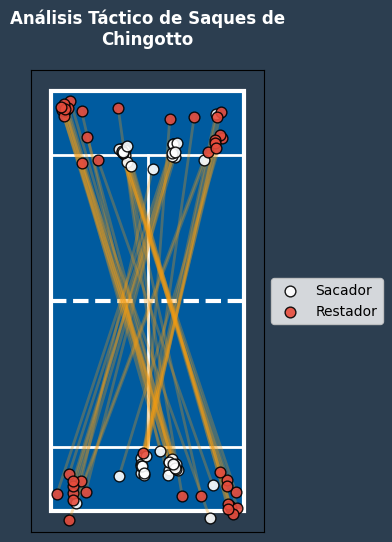

In [17]:
#| fig-align: center
cordX_saques = [saques_validos['origin_x'], saques_validos['destiny_x']]
cordY_saques = [saques_validos['origin_y'], saques_validos['destiny_y']]
plot_a_shot(
    title=f'Análisis Táctico de Saques de {player_name}',
    cordX=cordX_saques,
    cordY=cordY_saques,
    label1='Sacador',
    label2='Restador'
)

In [18]:
#| fig-align: center
from IPython.display import Markdown, display
display(Markdown(f"""# Dirección de los globos\nEl globo es uno de los recursos tácticos más importantes en el pádel. En esta sección desglosamos las trayectorias de todos los globos ejecutados por **{player_name}**, diferenciando entre los envíos paralelos y cruzados. Además, prestamos especial atención a los globos realizados desde el fondo de la pista, donde la presión defensiva suele ser mayor."""))

lob = all_events_from_match[all_events_from_match['type_of_shot'] == 'lob']
valid_lobs = lob.dropna(subset=['trajectory']) 


lob_with_nan_trajectorie = lob[lob['trajectory'].isna()]
df_valid_coords = lob_with_nan_trajectorie.dropna(subset=['origin_cord', 'destiny_cord']).copy()

origin_x = df_valid_coords['origin_cord'].str[0]
origin_y = df_valid_coords['origin_cord'].str[1]
destiny_x = df_valid_coords['destiny_cord'].str[0]
destiny_y = df_valid_coords['destiny_cord'].str[1]
df_valid_coords['trajectory'] = np.where(origin_x * destiny_x < 0, 'cross', 'parallel')

distancia_minima_y = 7.0
df_nan_clean = df_valid_coords[abs(origin_y - destiny_y) > distancia_minima_y].copy()

final_df = pd.concat([df_nan_clean, valid_lobs]).sort_index().reset_index(drop=True)


# Dirección de los globos
El globo es uno de los recursos tácticos más importantes en el pádel. En esta sección desglosamos las trayectorias de todos los globos ejecutados por **Chingotto**, diferenciando entre los envíos paralelos y cruzados. Además, prestamos especial atención a los globos realizados desde el fondo de la pista, donde la presión defensiva suele ser mayor.

In [19]:
#| fig-align: center
origin_y = final_df['origin_cord'].str[1]
destiny_y = final_df['destiny_cord'].str[1]

condicion_cruza_red = (origin_y * destiny_y) < 0

distancia_minima_profundidad = 3.0
condicion_globo_profundo = abs(destiny_y) > distancia_minima_profundidad

final_df = final_df[condicion_cruza_red & condicion_globo_profundo].copy()

In [20]:
#| fig-align: center
total_lobs = len(final_df)
cross_lobs = len(final_df[final_df['trajectory'] == 'cross'])

porcentaje_cross = (cross_lobs / total_lobs) * 100
porcentaje_parallel = 100 - porcentaje_cross
print(f"Porcentaje Cruzado de {player_name}: {porcentaje_cross:.2f}%")
print(f"Porcentaje Paralelo de {player_name}: {porcentaje_parallel:.2f}%")

Porcentaje Cruzado de Chingotto: 43.84%
Porcentaje Paralelo de Chingotto: 56.16%


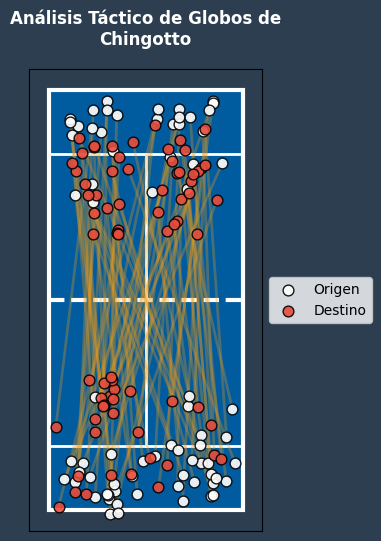

In [21]:
#| fig-align: center

plot_a_shot(
    title=f'Análisis Táctico de Globos de {player_name}', 
    cordX= [final_df['origin_cord'].str[0], final_df['destiny_cord'].str[0]],
    cordY= [final_df['origin_cord'].str[1], final_df['destiny_cord'].str[1]],
    label1='Origen',
    label2='Destino'
)

Porcentaje de globos paralelos de Chingotto desde el fondo de la pista: 57.78%
Porcentaje de globos cruzados de Chingotto desde el fondo de la pista: 42.22%


C:\Users\jjoaq\AppData\Local\Temp\ipykernel_11480\3078646896.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  backlobs = final_df[condition_back_lob].copy()


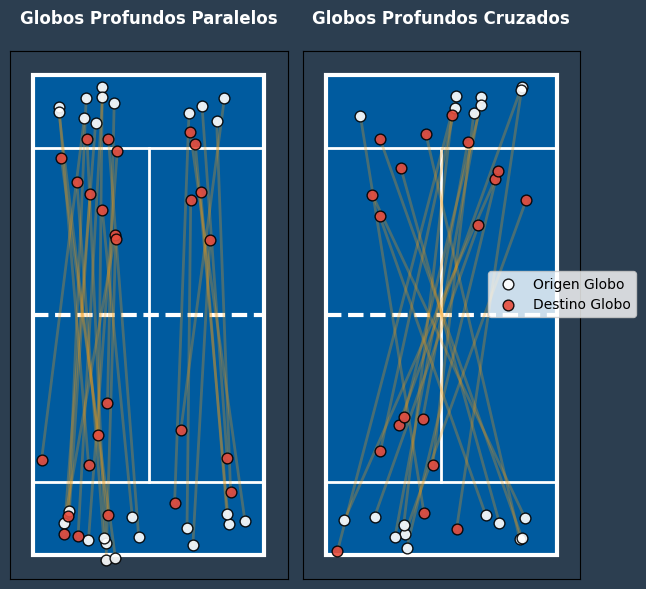

In [22]:
#| fig-align: center
condition_back_lob = abs(origin_y) > 8.0
backlobs = final_df[condition_back_lob].copy()
backlobs_parallel = backlobs[backlobs['trajectory'] == 'parallel']
backlobs_cross = backlobs[backlobs['trajectory'] == 'cross']

total = len(backlobs)
parallel = len(backlobs_parallel) 
percentage_back_lobs_parallel = (parallel / total) * 100
percentage_back_lobs_cross = 100 - percentage_back_lobs_parallel
print(f"Porcentaje de globos paralelos de {player_name} desde el fondo de la pista: {percentage_back_lobs_parallel:.2f}%")
print(f"Porcentaje de globos cruzados de {player_name} desde el fondo de la pista: {percentage_back_lobs_cross:.2f}%")
plot_two_shots(
    title1='Globos Profundos Paralelos', 
    cordX1=[backlobs_parallel['origin_cord'].str[0], backlobs_parallel['destiny_cord'].str[0]],
    cordY1=[backlobs_parallel['origin_cord'].str[1], backlobs_parallel['destiny_cord'].str[1]],
    
    title2='Globos Profundos Cruzados', 
    cordX2=[backlobs_cross['origin_cord'].str[0], backlobs_cross['destiny_cord'].str[0]],
    cordY2=[backlobs_cross['origin_cord'].str[1], backlobs_cross['destiny_cord'].str[1]],
    
    label1='Origen Globo',
    label2='Destino Globo'
)


In [23]:
#| fig-align: center
from IPython.display import Markdown, display
display(Markdown(f"""# Efectividad del globo\nNo basta con lanzar un buen globo; también es fundamental saber aprovecharlo. Aquí evaluamos la capacidad de **{player_name}** para tomar la iniciativa, analizando qué tipo de golpe ejecuta inmediatamente después de lograr un globo profundo para comprobar si consigue recuperar la red."""))

df_seq = all_events_from_match.copy()
df_seq = df_seq.sort_values(by=['match', 'frame']).reset_index(drop=True)

df_seq['destiny_y'] = df_seq['destiny_cord'].apply(lambda c: c[1] if isinstance(c, list) and len(c)==2 else 0)

df_seq['next_shot'] = df_seq['type_of_shot'].shift(-1)
df_seq['next_match'] = df_seq['match'].shift(-1) #Para asegurar que no mezclamos partidos

cond_globo = df_seq['type_of_shot'] == 'lob'
cond_profundo = abs(df_seq['destiny_y']) > 8.0
cond_mismo_partido = df_seq['match'] == df_seq['next_match']

globos_profundos = df_seq[cond_globo & cond_profundo & cond_mismo_partido]

#Resultados
efectividad = globos_profundos['next_shot'].value_counts(normalize=True) * 100
print("--- EFECTIVIDAD DEL GLOBO PROFUNDO ---")
print("¿Qué golpe se vio forzado a hacer el rival después de un globo profundo?")
for golpe, porcentaje in efectividad.items():
    if golpe == 'service':
        continue
    print(f"- {golpe}: {porcentaje:.1f}%")


# Efectividad del globo
No basta con lanzar un buen globo; también es fundamental saber aprovecharlo. Aquí evaluamos la capacidad de **Chingotto** para tomar la iniciativa, analizando qué tipo de golpe ejecuta inmediatamente después de lograr un globo profundo para comprobar si consigue recuperar la red.

--- EFECTIVIDAD DEL GLOBO PROFUNDO ---
¿Qué golpe se vio forzado a hacer el rival después de un globo profundo?
- smash: 43.8%
- lob: 25.0%
- volley: 18.8%
- drive: 12.5%


# Mapas de calor de Chingotto

Los mapas de calor nos ofrecen una radiografía perfecta de la movilidad. Observando las zonas más marcadas, podemos descubrir dónde se siente más cómodo **Chingotto** y cuáles son los espacios que más ocupa a lo largo del partido.

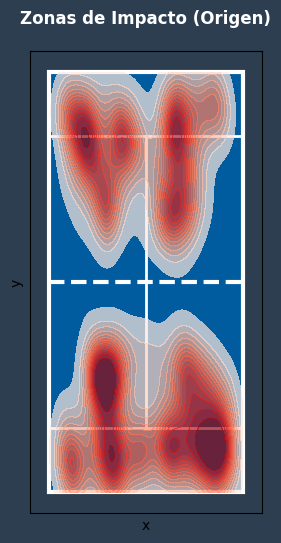

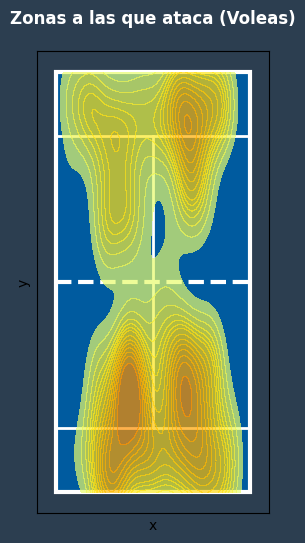

In [24]:
#| fig-align: center
from IPython.display import Markdown, display
display(Markdown(f"""# Mapas de calor de {player_name}\n\nLos mapas de calor nos ofrecen una radiografía perfecta de la movilidad. Observando las zonas más marcadas, podemos descubrir dónde se siente más cómodo **{player_name}** y cuáles son los espacios que más ocupa a lo largo del partido."""))

# 1. Mapa de Impactos (Zonas de Confort)
plot_heatmap(all_events_from_match, 'Zonas de Impacto (Origen)', 'origin_cord', cmap='Reds')

# 2. Mapa de Distribución
voleas = all_events_from_match[all_events_from_match['type_of_shot'] == 'volley']
plot_heatmap(voleas, 'Zonas a las que ataca (Voleas)', 'destiny_cord', cmap='Wistia')


In [25]:
#| fig-align: center
from IPython.display import display, Markdown

display(Markdown(f"""# Nevera (Análisis de participación de {player_name})\n
La "nevera" es una estrategia clásica que consiste en evitar jugar sobre uno de los rivales para aislarlo del juego. Analizando el volumen de bolas que golpea dentro de su propia pareja, podemos comprobar si los rivales han aplicado esta táctica sobre **{player_name}** o si ha estado muy participativo."""))

index_by_match = complete_player_df[['player_id', 'match']].drop_duplicates()
index_by_match = index_by_match.rename(columns={'player_id': 'audited_id'})
index_by_match['audited_id'] = index_by_match['audited_id'].astype(float).astype(int)

eventos_partidos = pd.merge(all_events_df, index_by_match, on='match')
eventos_partidos['player_id'] = eventos_partidos['player_id'].astype(float).astype(int)
eventos_partidos['rol'] = eventos_partidos.apply(asignar_rol, axis=1)

eventos_equipo = eventos_partidos[eventos_partidos['rol'].isin(['Auditado', 'Compañero'])]
porcentaje_nevera = eventos_equipo['rol'].value_counts(normalize=True) * 100

print("Porcentaje de volumen de juego dentro de la pareja:")
for rol, porcentaje in porcentaje_nevera.items():
    print(f"- {rol}: {porcentaje:.1f}%")


    


# Nevera (Análisis de participación de Chingotto)

La "nevera" es una estrategia clásica que consiste en evitar jugar sobre uno de los rivales para aislarlo del juego. Analizando el volumen de bolas que golpea dentro de su propia pareja, podemos comprobar si los rivales han aplicado esta táctica sobre **Chingotto** o si ha estado muy participativo.

Porcentaje de volumen de juego dentro de la pareja:
- Auditado: 53.0%
- Compañero: 47.0%
